# Proyecto Final Análisis de Datos

Integrantes:	Hans Munster, Ariel Gonzalez, Patricio Fonseca, Víctor Zúñiga

Profesora: 	Melanie Oyarzún

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pandas_datareader import wb

## Preparación de Datos

### Carga de datos Banco Mundial

In [2]:
df_GPDpc_comparison = wb.download(
                    #Use the indicator attribute to identify which indicator or indicators to download
                    indicator=['NY.GDP.PCAP.KD','TX.VAL.TECH.MF.ZS','GB.XPD.RSDV.GD.ZS'],
                    #Use the country attribute to identify the countries you want data for
                    country='all',
                    #Identify the first year for which you want the data, as an integer or a string
                    start=2020,
                    #Identify the last year for which you want the data, as an integer or a string
                    end=2020
                )

df_GPDpc_comparison = df_GPDpc_comparison.reset_index()

# drop column year
df_GPDpc_comparison.drop(columns=['year'], inplace=True)

# rename the columns name to more meaningful names
df_GPDpc_comparison.rename(columns={'NY.GDP.PCAP.KD':'gdp_pc'}, inplace=True)
df_GPDpc_comparison.rename(columns={'GB.XPD.RSDV.GD.ZS':'res_expend'}, inplace=True)
df_GPDpc_comparison.rename(columns={'TX.VAL.TECH.MF.ZS':'ht_export'}, inplace=True)

countries=wb.get_countries()

# to df_GPDpc_comparison add the columns iso3c and region from countries on country column in df_GPDpc_comparison and name column in countries
df_GPDpc_comparison = df_GPDpc_comparison.merge(countries[['name','iso3c','region']], left_on='country', right_on='name')

# drop column name and values Aggregates in region
df_GPDpc_comparison.drop(columns=['name'], inplace=True)
df_GPDpc_comparison.drop(df_GPDpc_comparison[df_GPDpc_comparison.region == 'Aggregates'].index, inplace=True)

### Carga de ECI

In [3]:
url_1 = "https://raw.githubusercontent.com/munsterinc1/ccr_1995_2001/main/eci_hs6_hs96_trade.csv"
url_2 = "https://raw.githubusercontent.com/munsterinc1/ccr_1995_2001/main/eci_research.csv"
url_3 = "https://raw.githubusercontent.com/munsterinc1/ccr_1995_2001/main/eci_tech.csv"

df_eci_tra = pd.read_csv(url_1)
df_eci_res = pd.read_csv(url_2)
df_eci_tech = pd.read_csv(url_3)

df_eci_tra.drop(df_eci_tra.columns.difference(['2020','Country','Country ID']), 1, inplace=True)
df_eci_res.drop(df_eci_res.columns.difference(['2020','Country','Country ID']), 1, inplace=True)
df_eci_tech.drop(df_eci_tech.columns.difference(['2020','Country','Country ID']), 1, inplace=True)

df_eci_tra.rename(columns={'2020':'eci_tra'}, inplace=True)
df_eci_res.rename(columns={'2020':'eci_res'}, inplace=True)
df_eci_tech.rename(columns={'2020':'eci_tech'}, inplace=True)

eci = df_eci_tra.merge(df_eci_res[['eci_res','Country ID']], on='Country ID', how='outer')
eci = eci.merge(df_eci_tech[['eci_tech','Country ID']], on='Country ID', how='outer')
eci['Country ID'] = eci['Country ID'].str[-3:].str.upper()

<ipython-input-3-227bef6dee14>:9: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df_eci_tra.drop(df_eci_tra.columns.difference(['2020','Country','Country ID']), 1, inplace=True)
<ipython-input-3-227bef6dee14>:10: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df_eci_res.drop(df_eci_res.columns.difference(['2020','Country','Country ID']), 1, inplace=True)
<ipython-input-3-227bef6dee14>:11: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df_eci_tech.drop(df_eci_tech.columns.difference(['2020','Country','Country ID']), 1, inplace=True)


### Creación de dataframe data

In [4]:
# create a new dataframe data merging df_GPDpc_comparison with eci on Country ID and iso3c. only merge with columns eci_tra, eci_res and eci_tech
data = pd.merge(df_GPDpc_comparison, eci[['Country ID','eci_tra','eci_res','eci_tech']], left_on='iso3c', right_on='Country ID', how='left')

# in data drop column country
data.drop(columns=['Country ID'], inplace=True)

# in data reorder the columns
data = data[['country','iso3c','region','gdp_pc','res_expend','ht_export','eci_tra','eci_res','eci_tech']]

# drop rows eith gdpc_pc = NaN
data.dropna(subset=['gdp_pc'], inplace=True)
data.head()

,country,iso3c,region,gdp_pc,res_expend,ht_export,eci_tra,eci_res,eci_tech
0,Afghanistan,AFG,South Asia,553.036131,NaN,NaN,-1.185703,-1.152204,NaN
1,Albania,ALB,Europe & Central Asia,4418.660885,NaN,0.285854,-0.337132,-0.315437,-1.021958
2,Algeria,DZA,Middle East & North Africa,3873.508733,NaN,NaN,-1.206390,-0.976323,-0.466942
3,American Samoa,ASM,East Asia & Pacific,14303.627033,NaN,NaN,NaN,NaN,NaN
4,Andorra,AND,Europe & Central Asia,34394.414041,NaN,NaN,NaN,NaN,NaN


In [5]:
# Creación de columna log_gdp_pc para cambiar la escala de la variable dependiente (Transformación logarítmica)
import numpy as np
data['log_gdp_pc'] = np.log(data['gdp_pc'])
data.head()

,country,iso3c,region,gdp_pc,res_expend,ht_export,eci_tra,eci_res,eci_tech,log_gdp_pc
0,Afghanistan,AFG,South Asia,553.036131,NaN,NaN,-1.185703,-1.152204,NaN,6.315423
1,Albania,ALB,Europe & Central Asia,4418.660885,NaN,0.285854,-0.337132,-0.315437,-1.021958,8.393592
2,Algeria,DZA,Middle East & North Africa,3873.508733,NaN,NaN,-1.206390,-0.976323,-0.466942,8.261916
3,American Samoa,ASM,East Asia & Pacific,14303.627033,NaN,NaN,NaN,NaN,NaN,9.568268
4,Andorra,AND,Europe & Central Asia,34394.414041,NaN,NaN,NaN,NaN,NaN,10.445649


In [6]:
data.shape

(207, 10)

In [7]:
data = data.dropna() # Eliminación de filas con valores faltantes
data.shape

(59, 10)

## Describiendo la Data

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_pc,59.0,21629.523115,18775.297240,2350.400146,6150.054901,14774.989199,35157.670128,79074.540135
res_expend,59.0,1.377188,1.239324,0.048930,0.308395,1.093710,2.064325,5.354510
ht_export,59.0,13.724979,12.556813,0.608342,5.951606,9.913521,18.013386,69.646893
eci_tra,59.0,0.665151,0.735121,-1.206635,0.052458,0.763129,1.230128,2.190883
eci_res,59.0,0.462652,1.022719,-1.517296,-0.335002,0.277009,1.398078,2.537689
eci_tech,59.0,0.386020,0.843140,-2.040314,-0.238452,0.673498,1.019290,1.551410
log_gdp_pc,59.0,9.589056,0.933113,7.762341,8.724079,9.600691,10.467474,11.278146


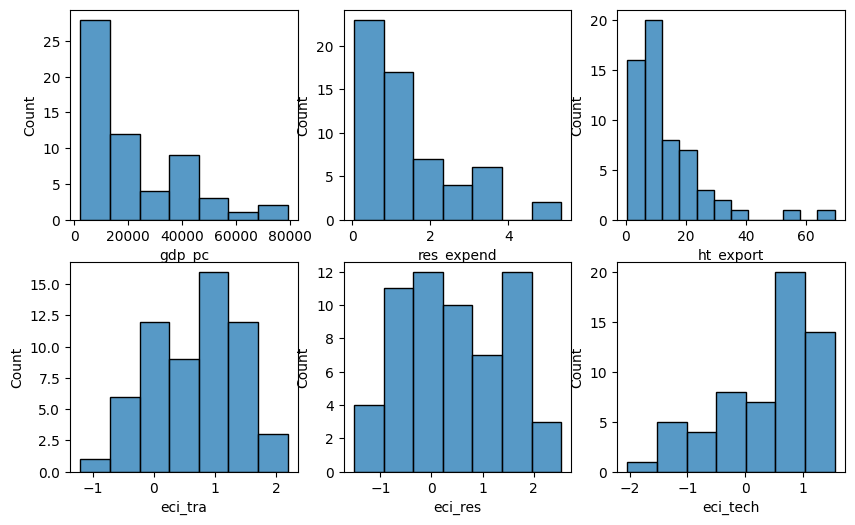

In [8]:
# plot histogram for each variable. 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
# fig.suptitle('Histograms')
sns.histplot(ax=axes[0, 0], data=data, x="gdp_pc")
sns.histplot(ax=axes[0, 1], data=data, x="res_expend")
sns.histplot(ax=axes[0, 2], data=data, x="ht_export")
sns.histplot(ax=axes[1, 0], data=data, x="eci_tra")
sns.histplot(ax=axes[1, 1], data=data, x="eci_res")
sns.histplot(ax=axes[1, 2], data=data, x="eci_tech")
plt.show()

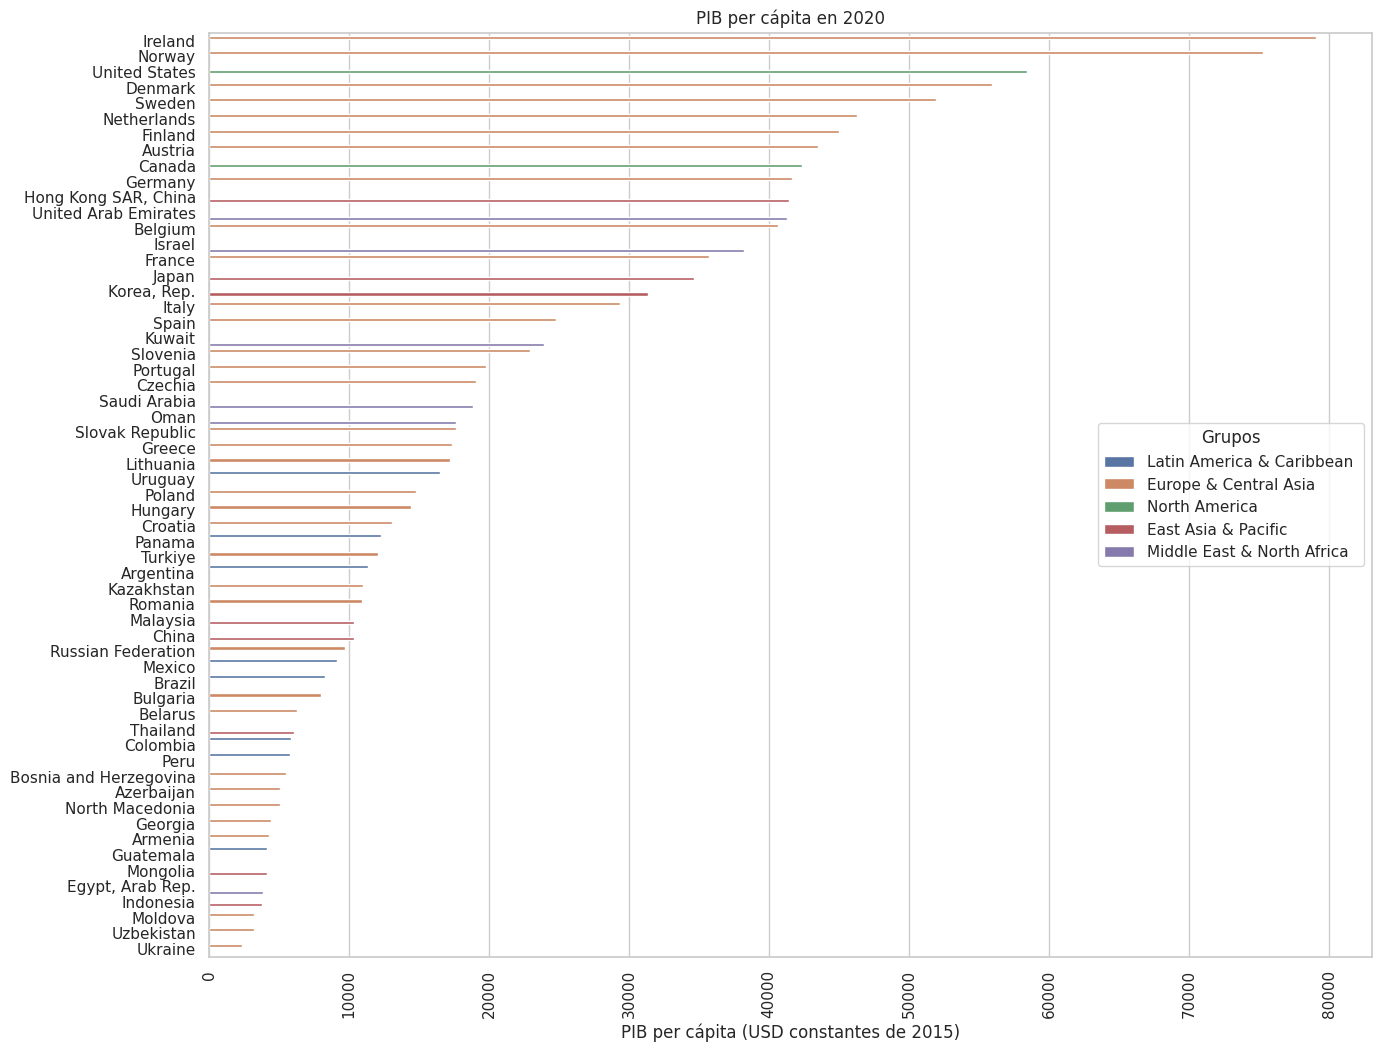

In [ ]:
sns.barplot(data=data, x='gdp_pc', y='country', hue='region', order=data.sort_values('gdp_pc', ascending=False)['country'], width=1)
# sns.barplot(data=df_GPDpc_comparison, x='NY.GDP.PCAP.KD', y='country', hue='group', order=df_GPDpc_comparison.sort_values('NY.GDP.PCAP.KD', ascending=False)['country']) # Promedio de PIB en dataframe

sns.set(style="whitegrid", rc={'figure.figsize':(15,12)})

plt.title('PIB per cápita en 2020')
plt.xlabel('PIB per cápita (USD constantes de 2015)')
plt.ylabel('')
plt.legend(title='Grupos')
plt.xticks(rotation=90)
plt.show()

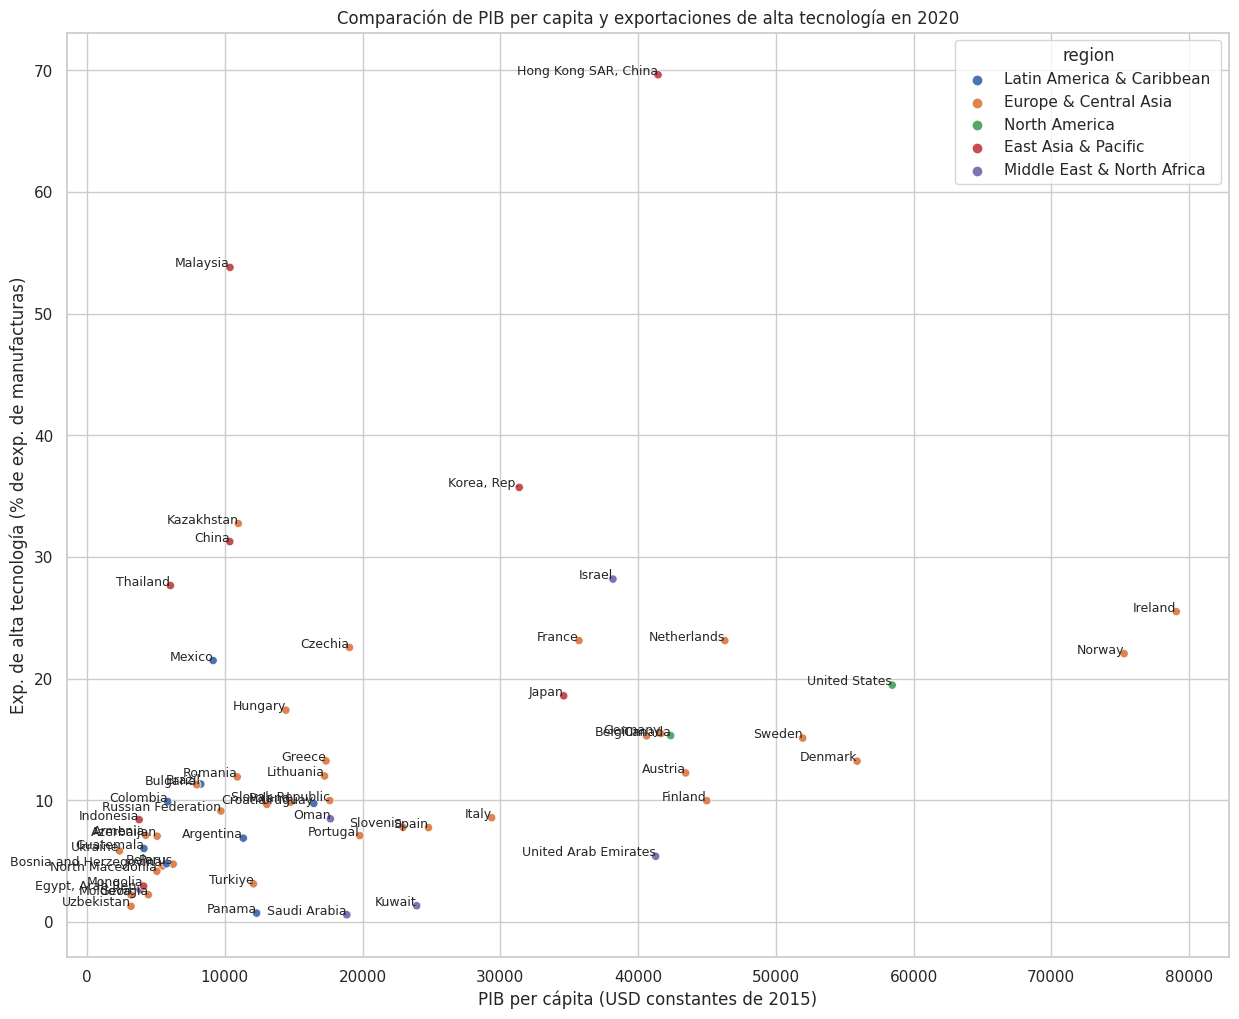

In [ ]:
ax = sns.scatterplot(data = data, x='gdp_pc', y='ht_export', hue='region', legend='full')

# Add country names to each dot
for i, row in data.iterrows():
    ax.annotate(row['country'], (row['gdp_pc'], row['ht_export']), fontsize=9, ha='right')

# Add a title and axis labels
plt.title('Comparación de PIB per capita y exportaciones de alta tecnología en 2020')
plt.xlabel('PIB per cápita (USD constantes de 2015)')
plt.ylabel('Exp. de alta tecnología (% de exp. de manufacturas)')
# plt.legend('')

# Show the plot
plt.show()

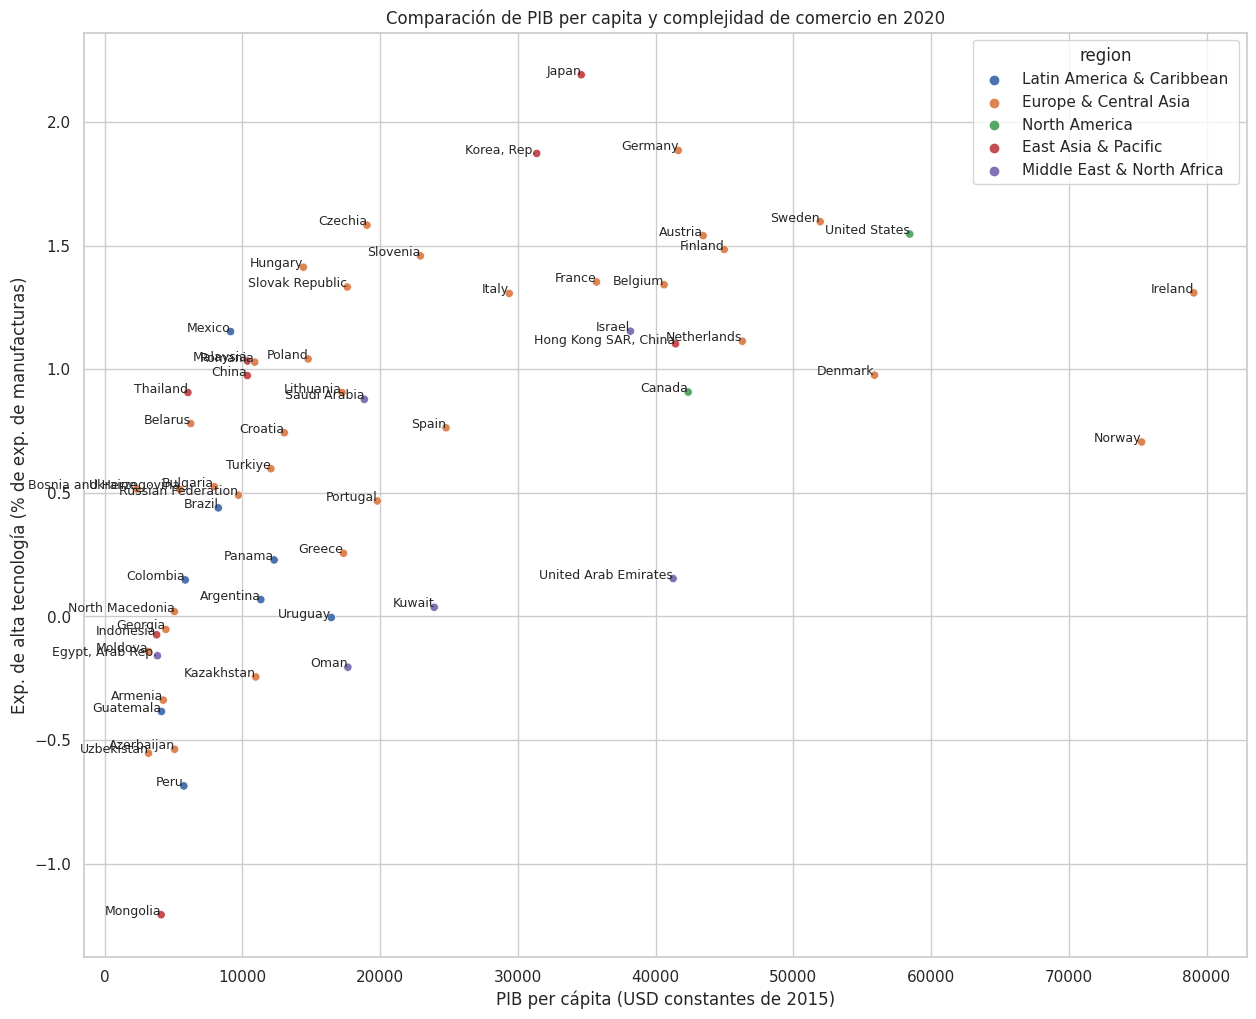

In [ ]:
ax = sns.scatterplot(data = data, x='gdp_pc', y='eci_tra', hue='region', legend='full')

# Add country names to each dot
for i, row in data.iterrows():
    ax.annotate(row['country'], (row['gdp_pc'], row['eci_tra']), fontsize=9, ha='right')

# Add a title and axis labels
plt.title('Comparación de PIB per capita y complejidad de comercio en 2020')
plt.xlabel('PIB per cápita (USD constantes de 2015)')
plt.ylabel('Exp. de alta tecnología (% de exp. de manufacturas)')
# plt.legend('')

# Show the plot
plt.show()

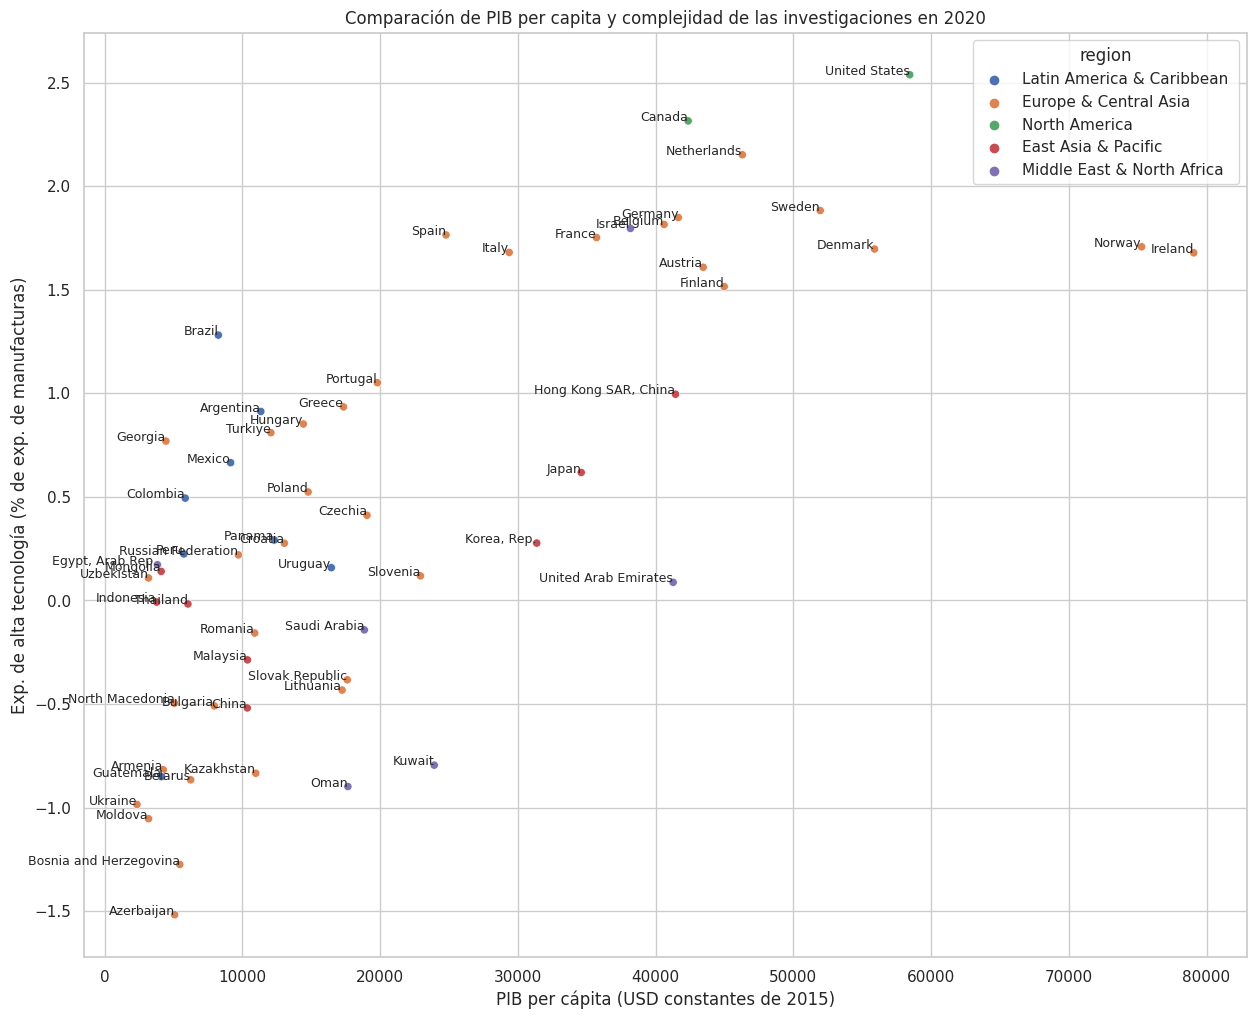

In [ ]:
ax = sns.scatterplot(data = data, x='gdp_pc', y='eci_res', hue='region', legend='full')

# Add country names to each dot
for i, row in data.iterrows():
    ax.annotate(row['country'], (row['gdp_pc'], row['eci_res']), fontsize=9, ha='right')

# Add a title and axis labels
plt.title('Comparación de PIB per capita y complejidad de las investigaciones en 2020')
plt.xlabel('PIB per cápita (USD constantes de 2015)')
plt.ylabel('Exp. de alta tecnología (% de exp. de manufacturas)')
# plt.legend('')

# Show the plot
plt.show()

Matriz de correlación

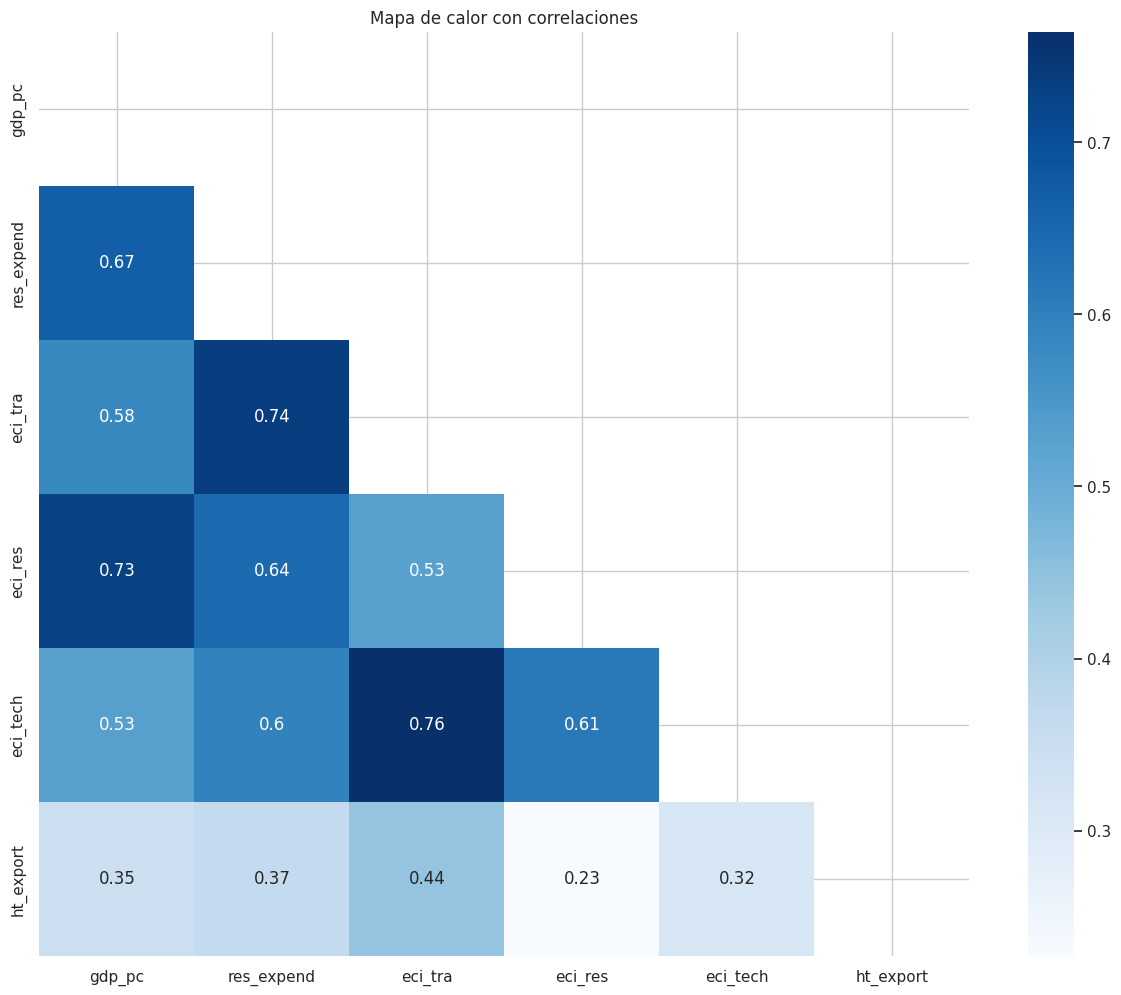

In [ ]:
corr = data[['gdp_pc','res_expend','eci_tra','eci_res','eci_tech','ht_export']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', mask=np.triu(corr)).set_title("Mapa de calor con correlaciones")
#set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);
plt.show()

Comparación de modelo a escala normal y logarímica

Text(0.5, 1.0, 'gdp pc log')

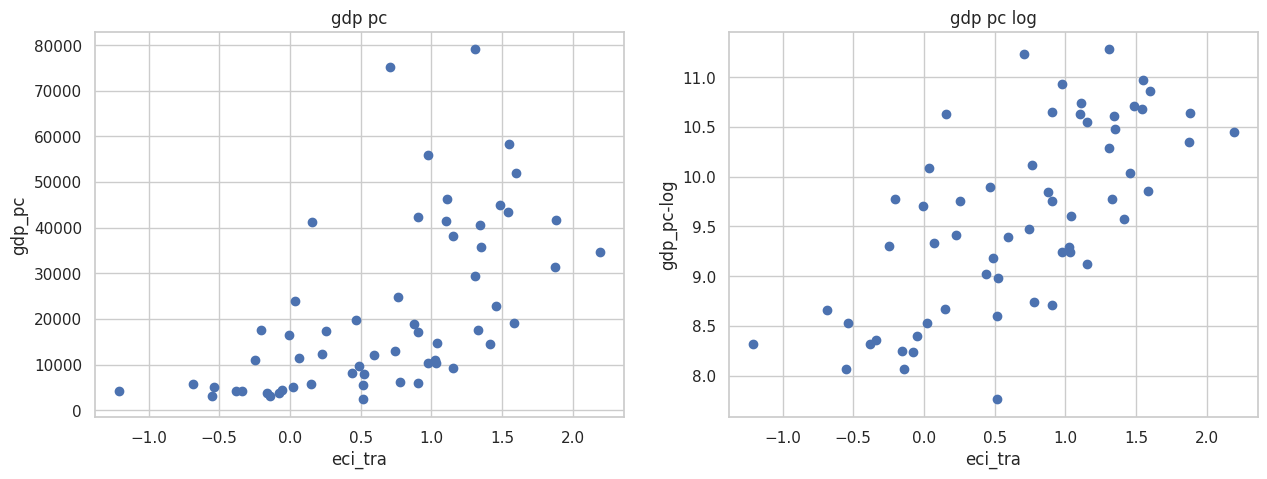

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot( 'eci_tra', 'gdp_pc', data=data, linestyle='none', marker='o')
ax[0].set_xlabel('eci_tra')
ax[0].set_ylabel('gdp_pc')
ax[0].set_title('gdp pc')

ax[1].plot( 'eci_tra', 'log_gdp_pc', data=data, linestyle='none', marker='o')
ax[1].set_xlabel("eci_tra")
ax[1].set_ylabel('gdp_pc-log')
ax[1].set_title('gdp pc log')

Modelo de regresión simple

In [ ]:
#Primer modelo regresión simple
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrs = smf.ols('gdp_pc ~ eci_tra', data = data)
mrs_result = mrs.fit()

# Imprimimos el resumen del modelo MPL
print(mrs_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 gdp_pc   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     28.97
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.44e-06
Time:                        14:18:23   Log-Likelihood:                -651.67
No. Observations:                  59   AIC:                             1307.
Df Residuals:                      57   BIC:                             1311.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.177e+04   2718.062      4.329      0.0

In [ ]:
print(mrs_result.params)
recta = 'Y=' +str(round(mrs_result.params[0],2))+'+'+ str(round(mrs_result.params[1],2))+'*X'
print(recta)

Intercept    11767.845386
eci_tra      14826.216058
dtype: float64
Y=11767.85+14826.22*X


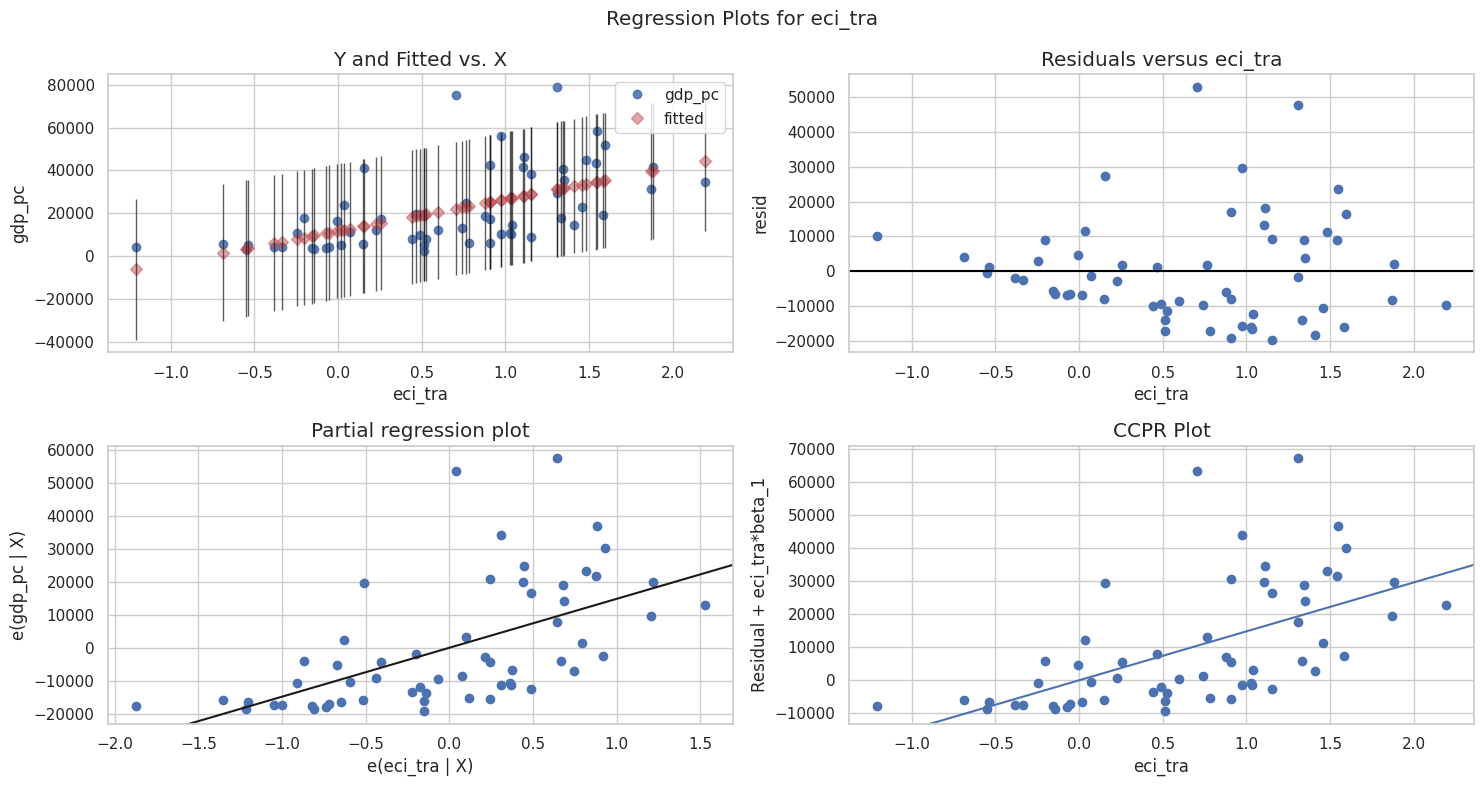

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrs_result, 'eci_tra', fig=fig)

Modelo regresión simple con transformación logarítmica (Modelo 1)

In [ ]:
#Primer modelo regresión simple con transformación logarítmica
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrs_log = smf.ols('log_gdp_pc ~ eci_tra', data = data)
mrs_log_result = mrs_log.fit()

# Imprimimos el resumen del modelo MPL
print(mrs_log_result.summary())

                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     51.82
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.49e-09
Time:                        14:18:27   Log-Likelihood:                -60.053
No. Observations:                  59   AIC:                             124.1
Df Residuals:                      57   BIC:                             128.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.0064      0.120     75.011      0.0

In [ ]:
print(mrs_log_result.params)
recta = 'Y=' +str(round(mrs_log_result.params[0],2))+'+'+ str(round(mrs_log_result.params[1],2))+'*X'
print(recta)

Intercept    9.006433
eci_tra      0.875926
dtype: float64
Y=9.01+0.88*X


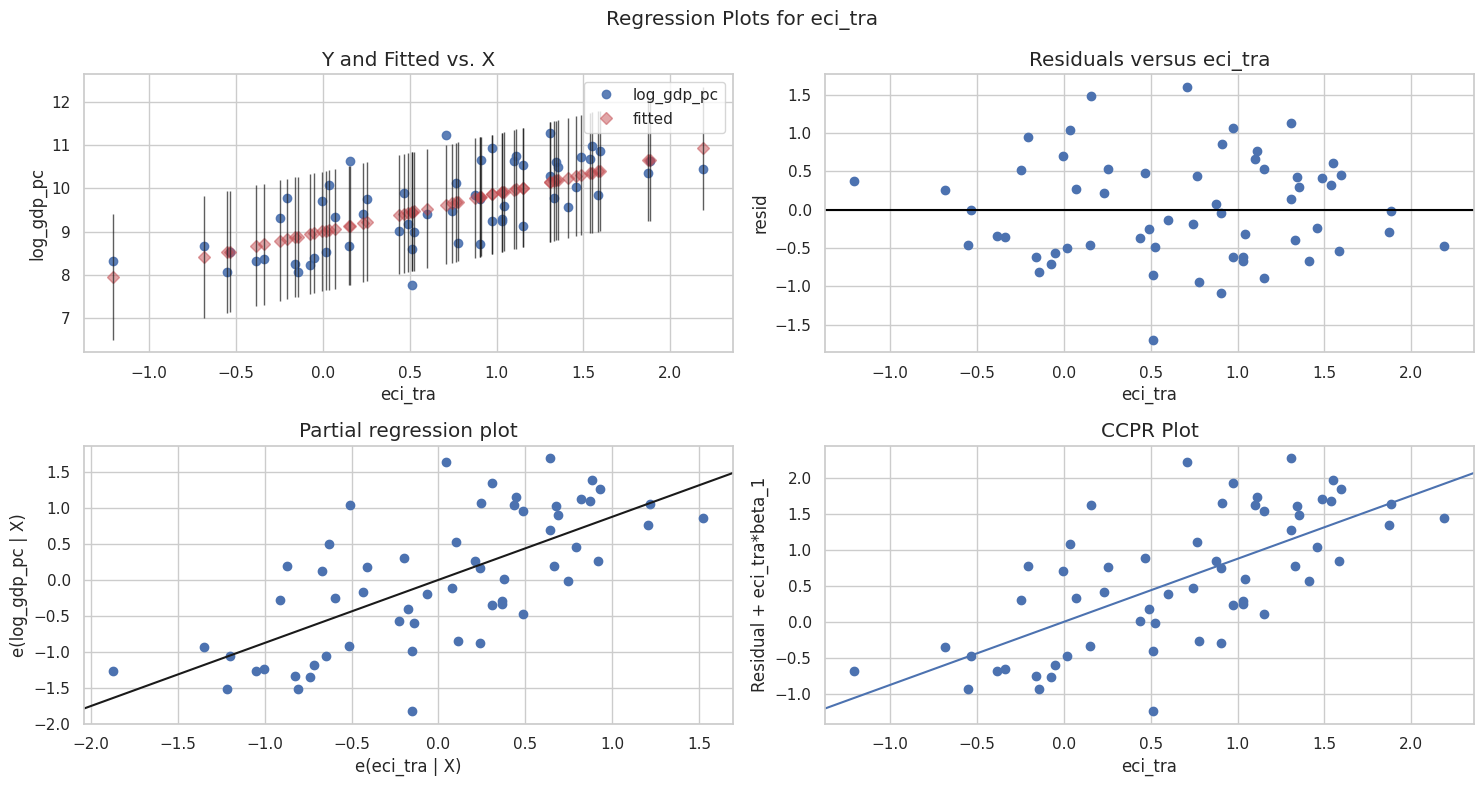

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrs_log_result, 'eci_tra', fig=fig)

Modelo regresión múltiple

In [ ]:
#Primer modelo regresión múltiple
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrm1 = smf.ols('gdp_pc ~ eci_res + eci_tra', data = data)
mrm1_result = mrm1.fit()

# Imprimimos el resumen del modelo MPL
print(mrm1_result.summary())


                            OLS Regression Results                            
Dep. Variable:                 gdp_pc   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     39.60
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.91e-11
Time:                        14:18:32   Log-Likelihood:                -637.79
No. Observations:                  59   AIC:                             1282.
Df Residuals:                      56   BIC:                             1288.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.202e+04   2167.858      5.546      0.0

In [ ]:
print(mrm1_result.params)
recta = 'Y=' +str(round(mrm1_result.params[0],2))+'+'+ str(round(mrm1_result.params[1],2))+'*X''+'+ str(round(mrm1_result.params[2],2))+'*Z'
print(recta)

Intercept    12023.844164
eci_res      10764.780309
eci_tra       6953.804116
dtype: float64
Y=12023.84+10764.78*X+6953.8*Z


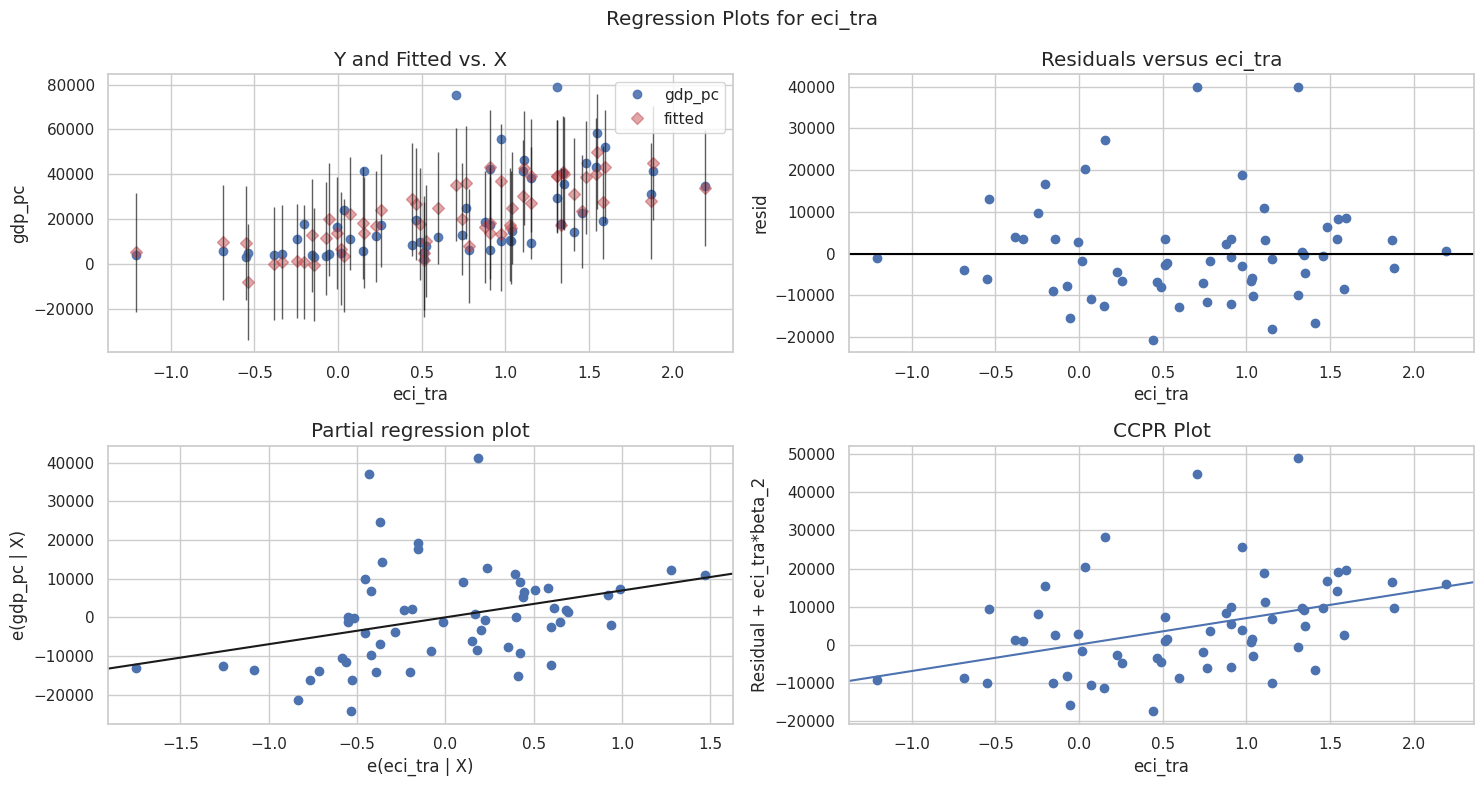

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrm1_result, 'eci_tra', fig=fig)

Modelo Regresión Múltiple con transformación logaritmica (Modelo 3)

In [ ]:
#Primer modelo regresión múltiple con transformación logarítmica
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrm1_log = smf.ols('log_gdp_pc ~ eci_res + eci_tra', data = data)
mrm1_log_result = mrm1_log.fit()

# Imprimimos el resumen del modelo MPL
print(mrm1_log_result.summary())


                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     53.03
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.20e-13
Time:                        14:17:53   Log-Likelihood:                -47.781
No. Observations:                  59   AIC:                             101.6
Df Residuals:                      56   BIC:                             107.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.0172      0.098     91.630      0.0

In [ ]:
print(mrm1_log_result.params)
recta = 'Y=' +str(round(mrm1_log_result.params[0],2))+'+'+ str(round(mrm1_log_result.params[1],2))+'*X''+'+ str(round(mrm1_log_result.params[2],2))+'*Y'
print(recta)

Intercept    9.017202
eci_res      0.452823
eci_tra      0.544771
dtype: float64
Y=9.02+0.45*X+0.54*Y


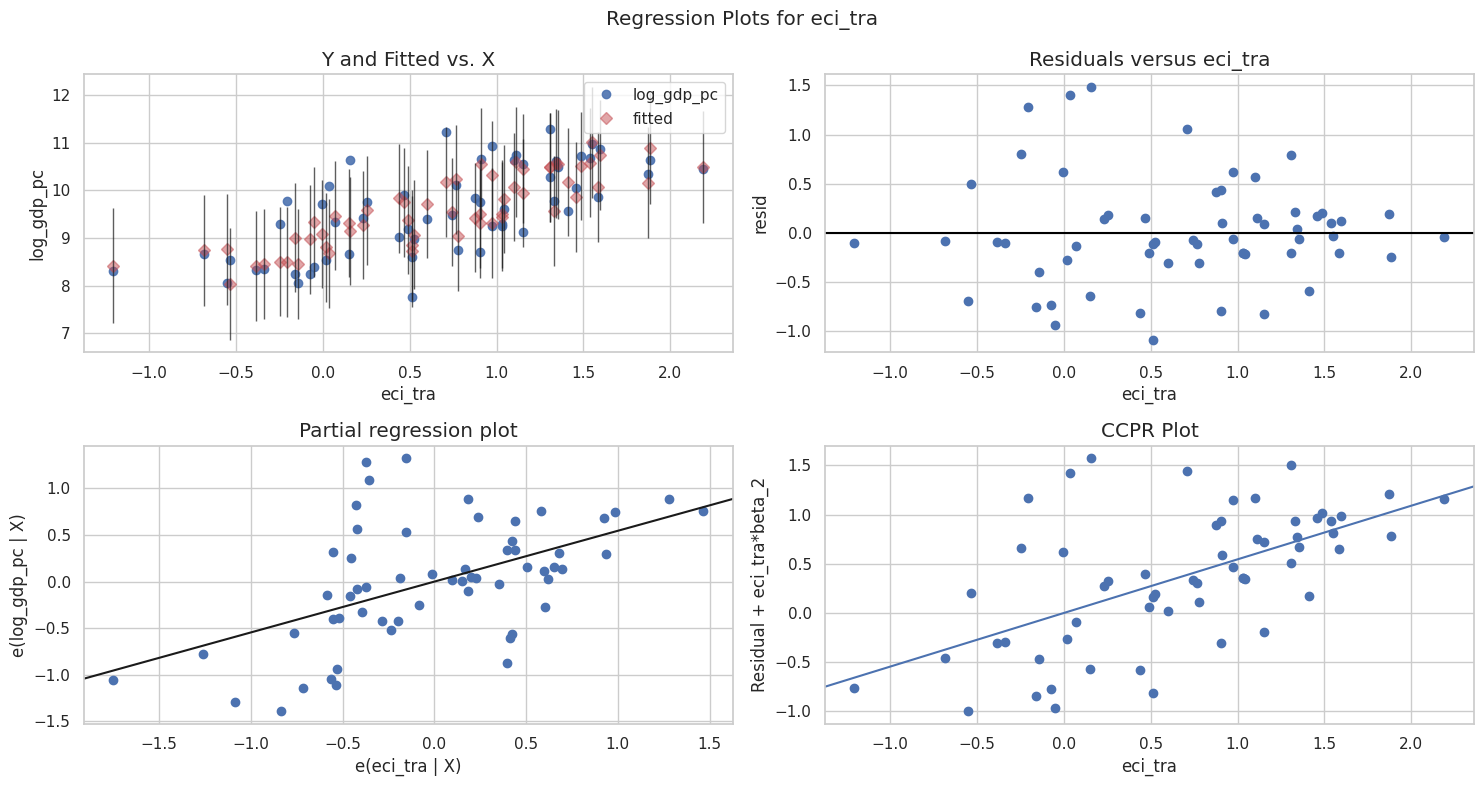

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrm1_log_result, 'eci_tra', fig=fig)

In [ ]:
pip install stargazer

In [ ]:
from stargazer.stargazer import Stargazer

stargazer = Stargazer([mrs_result, mrs_log_result, mrm1_result ,mrm1_log_result])
# personalizamos las etiquetas de las columnas
stargazer.custom_columns(['Modelo Reg. Lineal Simple', 'Modelo Reg. Lineal Simple (log)', 'Modelo Reg. Lineal Múltiple', 'Modelo Reg. Lineal Múltiple (log)'], [1,1,1,1])

#veamos la tabla
stargazer

Se puede observar que en el caso de los modelos en los que no se aplicó logaritmo, poseen un error estándar de los residuos más grande


Se toma la decisión de utilizar sólo modelos en escala logarítmica, debido a la magnitud de sus residios y a su buen ajuste.



---



Modelo 2

In [ ]:
#Primer modelo regresión simple con transformación logarítmica
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrs_log_1 = smf.ols('log_gdp_pc ~ eci_res', data = data)
mrs_log_1_result = mrs_log_1.fit()

# Imprimimos el resumen del modelo MPL
print(mrs_log_1_result.summary())

                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     62.04
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.10e-10
Time:                        14:18:00   Log-Likelihood:                -57.406
No. Observations:                  59   AIC:                             118.8
Df Residuals:                      57   BIC:                             123.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2843      0.093     99.610      0.0

In [ ]:
print(mrs_log_1_result.params)
recta = 'Y=' +str(round(mrs_log_1_result.params[0],2))+'+'+ str(round(mrs_log_1_result.params[1],2))+'*X'
print(recta)

Intercept    9.284326
eci_res      0.658659
dtype: float64
Y=9.28+0.66*X


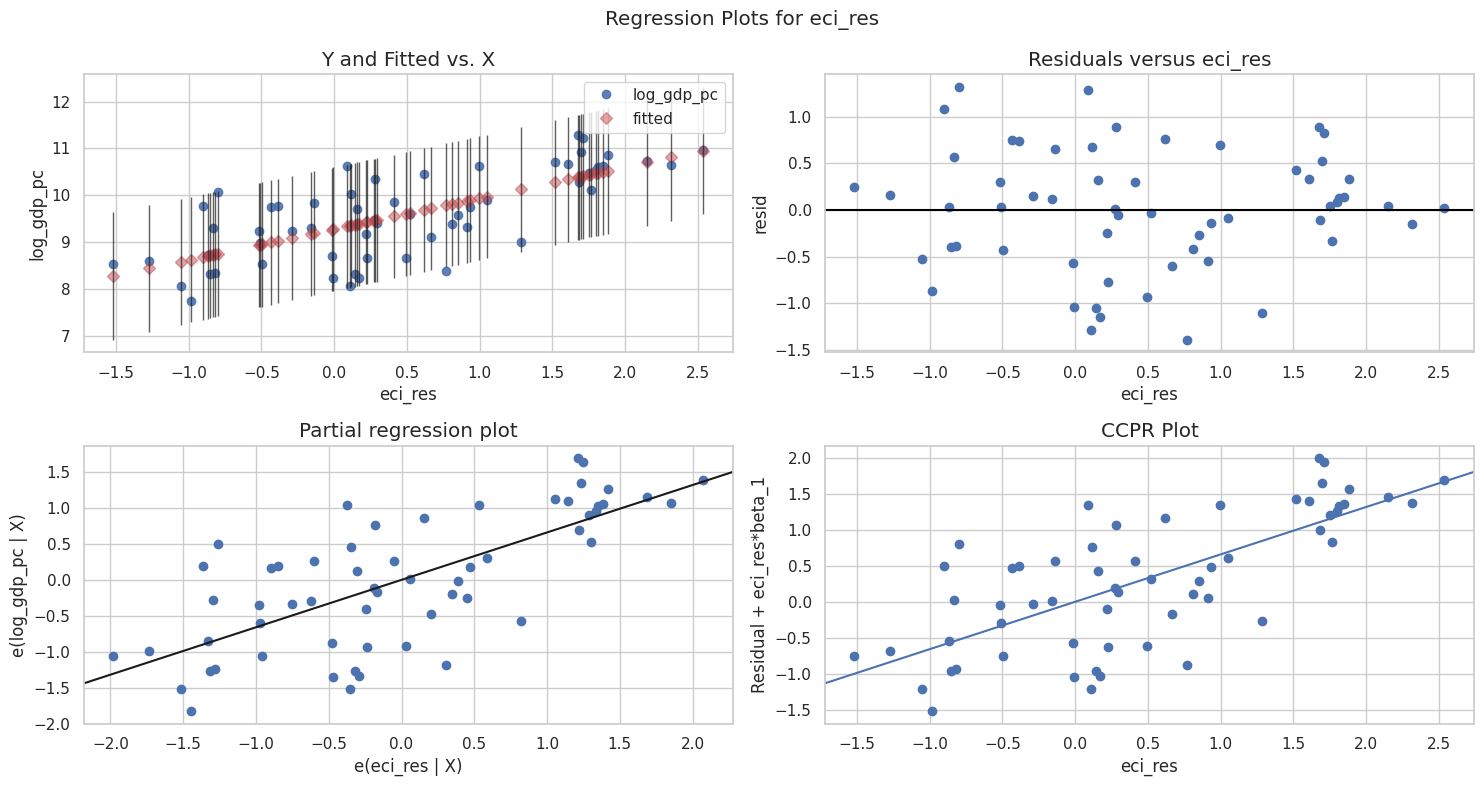

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrs_log_1_result, 'eci_res', fig=fig)

Modelo 4



In [ ]:
#Primer modelo regresión múltiple con transformación logarítmica
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrm2_log = smf.ols('log_gdp_pc ~ eci_res + eci_tra + ht_export' , data = data)
mrm2_log_result = mrm2_log.fit()

# Imprimimos el resumen del modelo MPL
print(mrm2_log_result.summary())


                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     35.91
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           5.46e-13
Time:                        14:18:03   Log-Likelihood:                -47.130
No. Observations:                  59   AIC:                             102.3
Df Residuals:                      55   BIC:                             110.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.9546      0.113     79.039      0.0

In [ ]:
print(mrm2_log_result.params)
recta = 'Y=' +str(round(mrm2_log_result.params[0],3))+'+'+ str(round(mrm2_log_result.params[1],3))+'*X''+'+ str(round(mrm2_log_result.params[2],3))+'*Y''+'+ str(round(mrm2_log_result.params[3],3))+'*Z'
print(recta)

Intercept    8.954613
eci_res      0.453465
eci_tra      0.489882
ht_export    0.007199
dtype: float64
Y=8.955+0.453*X+0.49*Y+0.007*Z


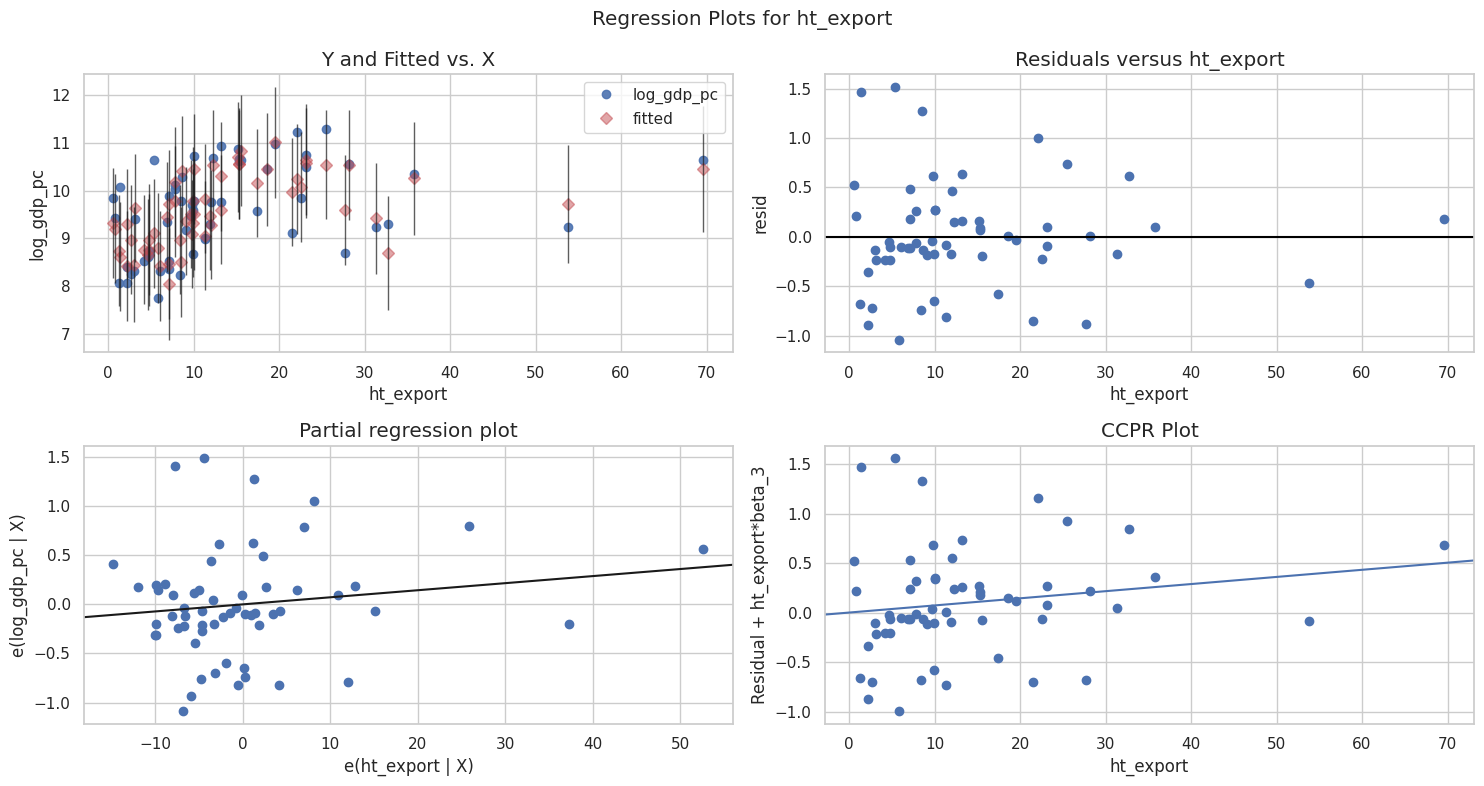

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrm2_log_result, 'ht_export', fig=fig)

Modelo 5

In [ ]:
#Primer modelo regresión múltiple con transformación logarítmica
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Estimamos un modelo (Regresión por mínimos cuadrados ordinarios)
mrm3_log = smf.ols('log_gdp_pc ~ eci_res + eci_tra + ht_export + res_expend' , data = data)
mrm3_log_result = mrm3_log.fit()

# Imprimimos el resumen del modelo MPL
print(mrm3_log_result.summary())

                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     28.21
Date:                Fri, 27 Oct 2023   Prob (F-statistic):           1.14e-12
Time:                        14:18:06   Log-Likelihood:                -45.851
No. Observations:                  59   AIC:                             101.7
Df Residuals:                      54   BIC:                             112.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.8773      0.123     72.445      0.0

In [ ]:
print(mrm2_log_result.params)
recta = 'Y=' +str(round(mrm3_log_result.params[0],4))+'+'+ str(round(mrm3_log_result.params[1],4))+'*X''+'+ str(round(mrm3_log_result.params[2],4))+'*Y''+'+ str(round(mrm3_log_result.params[3],4))+'*Z''+'+ str(round(mrm3_log_result.params[4],4))+'*A'
print(recta)

Intercept    8.954613
eci_res      0.453465
eci_tra      0.489882
ht_export    0.007199
dtype: float64
Y=8.8773+0.389*X+0.3577*Y+0.0064*Z+0.1493*A


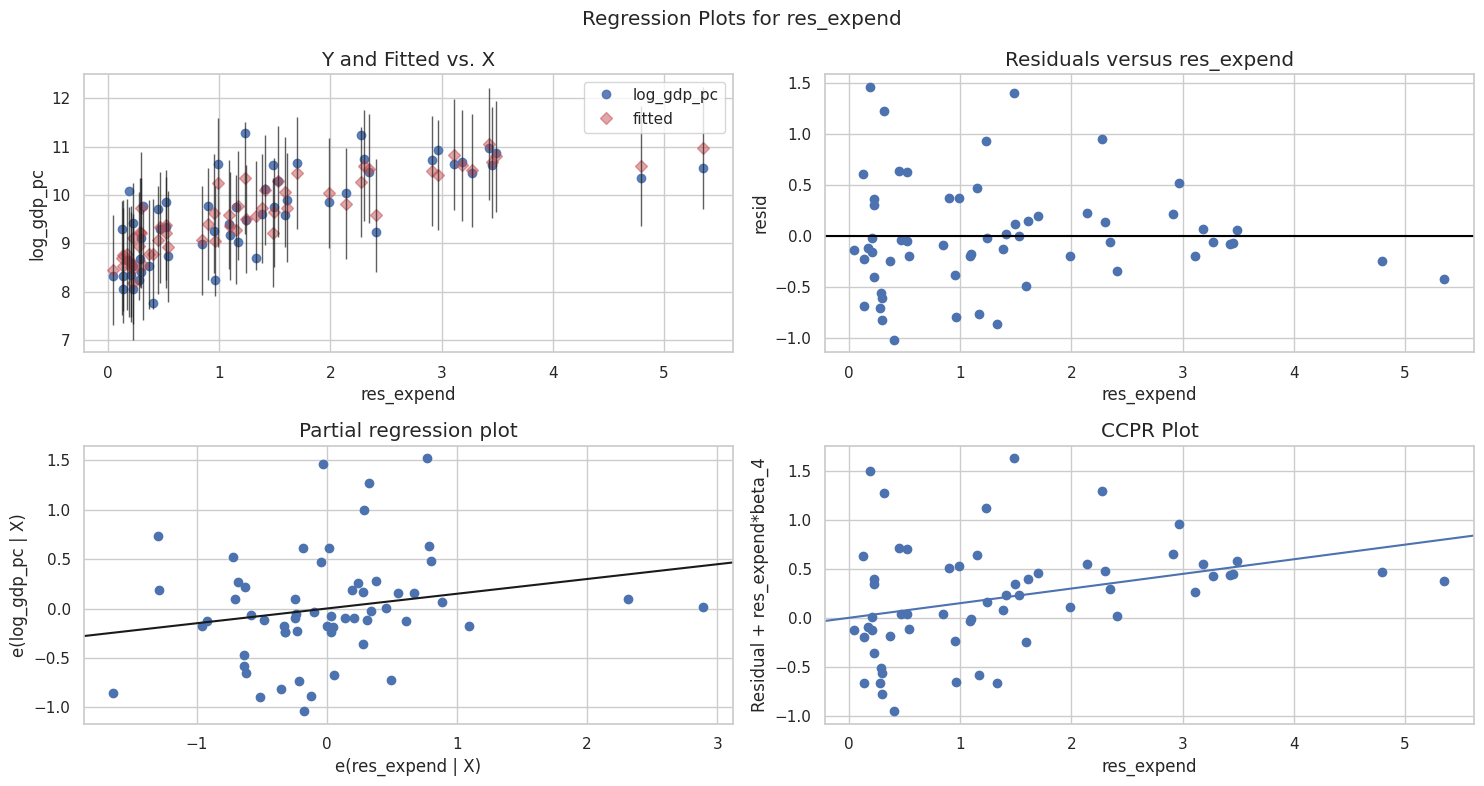

In [ ]:
fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(mrm3_log_result, 'res_expend', fig=fig)

Aplicación de Stargazer para comparación de modelos

In [ ]:
from stargazer.stargazer import Stargazer

stargazer = Stargazer([mrs_log_result , mrs_log_1_result , mrm1_log_result, mrm2_log_result, mrm3_log_result])
# personalizamos las etiquetas de las columnas
stargazer.custom_columns([ 'Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5'], [1,1,1,1,1])

#veamos la tabla
stargazer

### FIN